In [1]:
# check prophet version
import fbprophet
# print version number
print('Prophet %s' % fbprophet.__version__)

Prophet 0.7.1


In [7]:
# load the car sales dataset
from pandas import read_csv
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = read_csv(path, header=0)
# summarize shape
print(df.shape)
# show first few rows
print(df.head())

(108, 2)
     Month  Sales
0  1960-01   6550
1  1960-02   8728
2  1960-03  12026
3  1960-04  14395
4  1960-05  14587


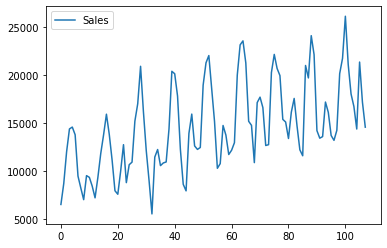

In [4]:

# load and plot the car sales dataset
from pandas import read_csv
from matplotlib import pyplot
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = read_csv(path, header=0)
# plot the time series
df.plot()
pyplot.show()

In [6]:
from pandas import to_datetime
# prepare expected column names
df.columns = ['ds', 'y']
df['ds']= to_datetime(df['ds'])
df.head()

,ds,y
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [10]:

# fit prophet model on the car sales dataset
from pandas import read_csv
from pandas import to_datetime
from fbprophet import Prophet
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = read_csv(path, header=0)
# prepare expected column names
df.columns = ['ds', 'y']
df['ds']= to_datetime(df['ds'])
# define the model
model = Prophet()
# fit the model
model.fit(df)

INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [12]:
from pandas import DataFrame
# define the period for which we want a prediction
future = list()
for i in range(1, 13):
	date = '1968-%02d' % i
	future.append([date])
future = DataFrame(future)
future.columns = ['ds']
future['ds']= to_datetime(future['ds'])

In [13]:
future

,ds
0,1968-01-01
1,1968-02-01
2,1968-03-01
3,1968-04-01
4,1968-05-01
5,1968-06-01
6,1968-07-01
7,1968-08-01
8,1968-09-01
9,1968-10-01


In [17]:
test = df.iloc[-12:,:].drop('y', axis=1)

          ds          yhat    yhat_lower    yhat_upper
0 1968-01-01  14334.737769  12814.561674  15769.164865
1 1968-02-01  14905.955964  13313.562586  16489.833389
2 1968-03-01  20842.150502  19416.387782  22347.100238
3 1968-04-01  22870.095215  21282.213894  24376.361749
4 1968-05-01  24176.211162  22601.903175  25783.610900


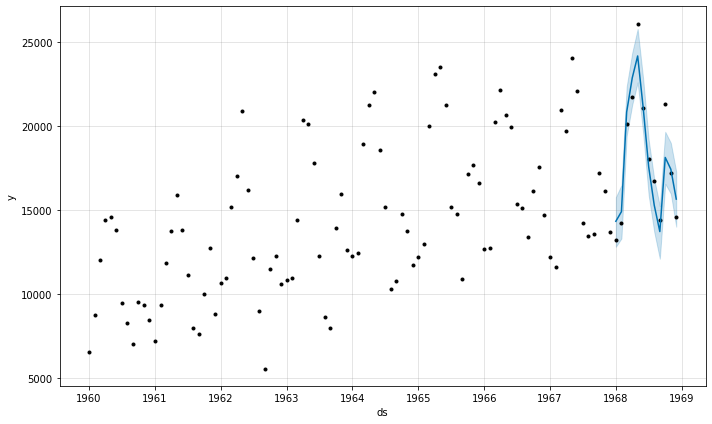

In [18]:
forecast = model.predict(test)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
# plot forecast
model.plot(forecast)
pyplot.show()

In [19]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1968-01-01,17795.101137,12814.561674,15769.164865,17795.101137,17795.101137,-3460.363368,-3460.363368,-3460.363368,-3460.363368,-3460.363368,-3460.363368,0.0,0.0,0.0,14334.737769
1,1968-02-01,17850.076787,13313.562586,16489.833389,17850.076787,17850.076787,-2944.120823,-2944.120823,-2944.120823,-2944.120823,-2944.120823,-2944.120823,0.0,0.0,0.0,14905.955964
2,1968-03-01,17901.505622,19416.387782,22347.100238,17901.505622,17901.505622,2940.644880,2940.644880,2940.644880,2940.644880,2940.644880,2940.644880,0.0,0.0,0.0,20842.150502
3,1968-04-01,17956.481273,21282.213894,24376.361749,17956.481273,17956.481273,4913.613942,4913.613942,4913.613942,4913.613942,4913.613942,4913.613942,0.0,0.0,0.0,22870.095215
4,1968-05-01,18009.683516,22601.903175,25783.610900,18009.683516,18009.683516,6166.527646,6166.527646,6166.527646,6166.527646,6166.527646,6166.527646,0.0,0.0,0.0,24176.211162
5,1968-06-01,18064.659167,19544.507290,22765.360430,18064.659167,18064.659167,2993.020023,2993.020023,2993.020023,2993.020023,2993.020023,2993.020023,0.0,0.0,0.0,21057.679190
6,1968-07-01,18117.861409,15890.838433,19185.231729,18117.861409,18117.861409,-532.371981,-532.371981,-532.371981,-532.371981,-532.371981,-532.371981,0.0,0.0,0.0,17585.489428
7,1968-08-01,18172.837060,13701.151775,16841.693676,18172.837060,18172.837060,-2883.575173,-2883.575173,-2883.575173,-2883.575173,-2883.575173,-2883.575173,0.0,0.0,0.0,15289.261887
8,1968-09-01,18227.812711,12106.849633,15232.250256,18227.812711,18227.812711,-4506.374429,-4506.374429,-4506.374429,-4506.374429,-4506.374429,-4506.374429,0.0,0.0,0.0,13721.438281
9,1968-10-01,18281.014954,16567.196385,19660.228758,18281.014954,18281.014954,-147.104077,-147.104077,-147.104077,-147.104077,-147.104077,-147.104077,0.0,0.0,0.0,18133.910877


In [20]:
# create test dataset, remove last 12 months
train = df.drop(df.index[-12:])
print(train.tail())

           ds      y
91 1967-08-01  13434
92 1967-09-01  13598
93 1967-10-01  17187
94 1967-11-01  16119
95 1967-12-01  13713


In [23]:
# define the model
model = Prophet()
# fit the model
model.fit(train)

INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [24]:
test = df.iloc[-12:,:].drop('y', axis=1)
test

,ds
96,1968-01-01
97,1968-02-01
98,1968-03-01
99,1968-04-01
100,1968-05-01
101,1968-06-01
102,1968-07-01
103,1968-08-01
104,1968-09-01
105,1968-10-01


In [26]:
test_y = df.iloc[-12:,1]
test_y

96     13210
97     14251
98     20139
99     21725
100    26099
101    21084
102    18024
103    16722
104    14385
105    21342
106    17180
107    14577
Name: y, dtype: int64

In [27]:
# use the model to make a forecast
forecast = model.predict(future)

In [30]:
y_pred = forecast['yhat'].values
mae = mean_absolute_error(test_y, y_pred)
mae

1336.813762330031

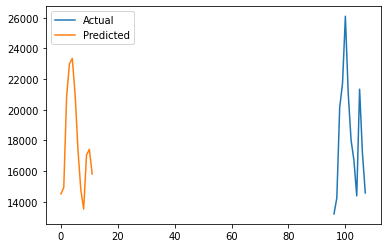

In [31]:
# plot expected vs actual
pyplot.plot(test_y, label='Actual')
pyplot.plot(y_pred, label='Predicted')
pyplot.legend()
pyplot.show()